# Project 2 Workbook: LendingClub XAI Professional Model Audit

This is the student workbook for the 2-week XAI project.

Primary dataset: LendingClub loan data.

Your goal is not only to build a strong model, but to audit how it behaves and where it fails.

## Submission Rules (Read First)

This workbook is graded on model quality plus audit quality.

Required:
1. M1 model artifact + validation metrics.
2. M2 local explanations for at least 3 failures (FP/FN).
3. M3 global dependency/interaction evidence.
4. M4 slicing analysis and mitigation proposal.

Coding expectation:
- Cells marked with `TODO REQUIRED` must be implemented by students.
- Do not leave placeholder defaults in required TODO blocks.

Not allowed:
- Plot dumping without interpretation.
- Claiming bias/fairness without subgroup metrics.
- Tuning on test set.

## Milestone Map

- M1: Black Box Model (performance first)
- M2: Local Detective (3 failure explanations)
- M3: Global Audit (importance, PDP, interactions)
- M4: Slicing + Audit Report (where model fails by subgroup and what to fix)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
from lime.lime_tabular import LimeTabularExplainer
from lightgbm import LGBMClassifier
import joblib

RANDOM_SEED = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 140)

## Team Configuration (Fill This)

Set your team metadata and assumptions before modeling.

In [ ]:
team_id = '1'
audit_focus = "model over-relies on int.rate and fico as safety proxies, missing defaults from low-rate high-FICO borrowers and over-flagging mid-FICO borrowers with recent inquiries"
threshold = 0.3  

print('Team:', team_id)
print('Audit focus:', audit_focus)
print('Initial threshold:', threshold)

Team: 1
Audit focus: TODO: e.g., false negatives in high-income applicants
Initial threshold: 0.3


## Part 1: Load LendingClub Data

Expected file location:
- data/lendingclub_loan_data.csv

If your file name is different, change DATA_FILE below.

In [4]:
DATA_DIR = Path('data')
DATA_FILE = DATA_DIR / 'lendingclub_loan_data.csv'

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f'Required LendingClub file not found: {DATA_FILE}. Place the CSV in project 2/data.'
    )

df_raw = pd.read_csv(DATA_FILE)
print('Loaded:', DATA_FILE)
print('Shape:', df_raw.shape)
display(df_raw.head(15))

Loaded: data\lendingclub_loan_data.csv
Shape: (9578, 15)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,loan_status
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,Fully Paid
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,Fully Paid
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,Fully Paid
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,Fully Paid
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,Fully Paid
5,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807,51.0,0,0,0,0,Fully Paid
6,1,debt_consolidation,0.1496,194.02,10.714418,4.00,667,3180.041667,3839,76.8,0,0,1,1,Charged Off
7,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220,68.6,0,0,0,1,Charged Off
8,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909,51.1,1,0,0,0,Fully Paid
9,1,debt_consolidation,0.1221,84.12,10.203592,10.00,707,2730.041667,5630,23.0,1,0,0,0,Fully Paid


In [5]:
df_raw.info()
df_raw.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
 14  loan_status        9578 non-null   str    
dtypes: float64(6), int64(7), str(2)
memory usage: 1.1 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,NaN,NaN,NaN,0.80497,0.396245,0.0,1.0,1.0,1.0,1.0
purpose,9578,7,debt_consolidation,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int.rate,9578.0,NaN,NaN,NaN,0.12264,0.026847,0.06,0.1039,0.1221,0.1407,0.2164
installment,9578.0,NaN,NaN,NaN,319.089413,207.071301,15.67,163.77,268.95,432.7625,940.14
log.annual.inc,9578.0,NaN,NaN,NaN,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,14.528354
dti,9578.0,NaN,NaN,NaN,12.606679,6.88397,0.0,7.2125,12.665,17.95,29.96
fico,9578.0,NaN,NaN,NaN,710.846314,37.970537,612.0,682.0,707.0,737.0,827.0
days.with.cr.line,9578.0,NaN,NaN,NaN,4560.767197,2496.930377,178.958333,2820.0,4139.958333,5730.0,17639.95833
revol.bal,9578.0,NaN,NaN,NaN,16913.963876,33756.189557,0.0,3187.0,8596.0,18249.5,1207359.0
revol.util,9578.0,NaN,NaN,NaN,46.799236,29.014417,0.0,22.6,46.3,70.9,119.0


## Part 2: Build Target and Core Features

Target for this workbook:
- `y = 1` for risky outcome (charged off/default/late-style statuses)

TODO (analysis-focused):
1. Inspect and print your dataset-specific `loan_status` values.
2. Complete risky label mapping for your file version.
3. Expand leakage filtering with justified columns.
4. Optional: add engineered features only if they improve explanation clarity.

In [6]:
df = df_raw.copy()

if 'loan_status' not in df.columns:
    raise ValueError('Expected a loan_status column in LendingClub dataset.')

# Inspect label space and keep this output in your report appendix.
status = df['loan_status'].astype(str).str.lower().str.strip()
display(status.value_counts(dropna=False).head(20))

# Expand risky token list only if your LendingClub file uses additional risky labels.
risky_tokens = [
    'charged off',
    'default',
    # 'late (31-120 days)',
    # 'does not meet the credit policy. status:charged off',
]
y = status.apply(lambda s: int(any(tok in s for tok in risky_tokens)))

# Starter leakage filters: add/remove based on your schema and explain choices in markdown.
leak_tokens = [
    'recover',
    'collection',
    'last_pymnt',
    'next_pymnt',
    'settlement',
]
feature_cols = []
for c in df.columns:
    lc = c.lower()
    if c == 'loan_status':
        continue
    if any(tok in lc for tok in leak_tokens):
        continue
    feature_cols.append(c)

X = df[feature_cols].copy()
X = X.drop(columns=['not.fully.paid'])  # This column is a direct leakage of the target and should be removed.

print('Positive rate:', round(float(y.mean()), 4))
print('Features:', X.shape[1])
display(X.head(2))

loan_status
fully paid     8045
charged off    1533
Name: count, dtype: int64

Positive rate: 0.1601
Features: 13


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0


In [7]:
# Optional: sample rows for faster iteration on student laptops.
MAX_ROWS = 120000
if len(X) > MAX_ROWS:
    idx = np.random.default_rng(RANDOM_SEED).choice(len(X), size=MAX_ROWS, replace=False)
    X = X.iloc[idx].reset_index(drop=True)
    y = y.iloc[idx].reset_index(drop=True)

print('Working rows:', len(X))

Working rows: 9578


## Part 3: Train / Validation / Test Split

In [8]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_val
)

print('Train:', len(X_train), 'Val:', len(X_val), 'Test:', len(X_test))
print('Rates train/val/test:', round(float(y_train.mean()),4), round(float(y_val.mean()),4), round(float(y_test.mean()),4))

Train: 5746 Val: 1916 Test: 1916
Rates train/val/test: 0.1599 0.1602 0.1602


## M1: The Black Box

Deliverable requirements:
1. Train one strong baseline model (provided LightGBM config is enough).
2. Report validation AUC and F1 at your chosen threshold.
3. Save model artifact (`.pkl`).
4. Write 3-5 lines on threshold trade-offs and error types.

Note: Hyperparameter tuning is optional, not required. Prioritize explanation depth in M2-M4.

In [9]:
numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# TODO REQUIRED: Build the preprocessing pipeline.
# Hint:
# 1) Numeric pipeline: median imputer
# 2) Categorical pipeline: most_frequent imputer + OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

# TODO REQUIRED: Fit transform on train, transform on val/test.
X_train_t = preprocessor.fit_transform(X_train, y_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

feature_names = numeric_cols + categorical_cols

if preprocessor is None or X_train_t is None or X_val_t is None or X_test_t is None:
    raise NotImplementedError('Complete TODO REQUIRED preprocessing block before continuing.')

In [10]:
# Baseline model config (sufficient for this project).
params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': -1,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_SEED,
}

model = LGBMClassifier(**params)
model.fit(X_train_t, y_train)

val_proba = model.predict_proba(X_val_t)[:, 1]

# TODO REQUIRED: Implement threshold comparison table on validation set.
# Required output columns: threshold, f1, positive_prediction_rate
threshold_grid = [0.3, 0.4, 0.5, 0.6]
threshold_table = pd.DataFrame(
    columns=['threshold', 'f1', 'positive_prediction_rate'],
    data=[
        [t, f1_score(y_val, (val_proba >= t).astype(int)), (val_proba >= t).mean()]
        for t in threshold_grid
    ]
)
display(threshold_table)

# TODO REQUIRED: choose final threshold using your analysis above.
# Update the `threshold` variable (defined in Team Configuration) if needed.
val_pred = (val_proba >= threshold).astype(int)
print('Validation ROC-AUC:', round(roc_auc_score(y_val, val_proba), 4))
print('Validation F1:', round(f1_score(y_val, val_pred), 4))
print('Confusion matrix (val):')
display(pd.DataFrame(confusion_matrix(y_val, val_pred), index=['actual_0','actual_1'], columns=['pred_0','pred_1']))

precision, recall, f1, _ = classification_report(y_val, val_pred, output_dict=True)['1'].values()
print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}')

if threshold_table is None:
    raise NotImplementedError('Complete TODO REQUIRED threshold_table before finalizing M1.')

[LightGBM] [Info] Number of positive: 919, number of negative: 4827
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1831
[LightGBM] [Info] Number of data points in the train set: 5746, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.159937 -> initscore=-1.658694
[LightGBM] [Info] Start training from score -1.658694


,threshold,f1,positive_prediction_rate
0,0.3,0.245473,0.099165
1,0.4,0.123077,0.043319
2,0.5,0.081159,0.019833
3,0.6,0.043750,0.006785


Validation ROC-AUC: 0.6361
Validation F1: 0.2455
Confusion matrix (val):


,pred_0,pred_1
actual_0,1480,129
actual_1,246,61


Precision: 0.3211, Recall: 0.1987, F1: 0.2455


In [11]:
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump({'model': model, 'preprocessor': preprocessor, 'feature_names': feature_names}, ARTIFACT_DIR / 'm1_lendingclub_model.pkl')
print('Saved:', ARTIFACT_DIR / 'm1_lendingclub_model.pkl')

Saved: artifacts\m1_lendingclub_model.pkl


## M1 Reflection (Write Here)

- What metric trade-off do you observe?
- Is your current threshold operationally reasonable?
- What is your biggest model limitation at this stage?



Answers:
- As the threshold increases from 0.3 to 0.6, both F1 and positive prediction rate drop sharply. This reflects a precision-recall tradeoff, higher thresholds make the model reduce false positives but missing far more actual defaults. At 0.6 the model barely flags any loans as risky, making it operationally useless for default detection.

- As threshold 0.3 is operationally reasonable for credit risk. If default cost is missed then the entire loan is a larger loss than incorrectly denying a loan and losing a potential interest revenue. Now 0.3 makes it a priority to catch most defaults even at the cost of some false positives, which aligns with the bank's risk tolerance.

- The validation ROC-AUC of 0.636 indicates that the model is only marginally better than random chance. This suggests the available features do not fully capture default risk, and the model may struggle to generalize reliably across different borrower subgroups.

## M2: Local Detective

Deliverable requirements:
1. Select at least 3 failure cases (FP/FN).
2. Explain each case with SHAP and/or LIME.
3. Write case-by-case interpretation notes.

In [14]:
val_results = pd.DataFrame({
    'y_true': y_val.values,
    'y_prob': val_proba,
    'y_pred': val_pred,
    'fico': X_val['fico'].values,
    'purpose': X_val['purpose'].values,
    'log.annual.inc': X_val['log.annual.inc'].values
}, index=X_val.index)

fp_idx = val_results[(val_results['y_true'] == 0) & (val_results['y_pred'] == 1)].index.tolist()
fn_idx = val_results[(val_results['y_true'] == 1) & (val_results['y_pred'] == 0)].index.tolist()

print('False positives:', len(fp_idx))
print('False negatives:', len(fn_idx))
display(val_results.head(15))

fp_confident = val_results[(val_results['y_true']==0) & (val_results['y_pred']==1)].nlargest(3, 'y_prob')
fn_confident = val_results[(val_results['y_true']==1) & (val_results['y_pred']==0)].nsmallest(3, 'y_prob')
print("Confident FPs:\n", fp_confident)
print("Confident FNs:\n", fn_confident)

# TODO REQUIRED: Build selected_cases with at least 3 ids including both FP and FN examples.
# Example target structure: [fp_idx[0], fp_idx[1], fn_idx[0]]
selected_cases = [7992, 8537, 3627] 

False positives: 129
False negatives: 246


,y_true,y_prob,y_pred,fico,purpose,log.annual.inc
3148,0,0.016242,0,752,home_improvement,11.561716
8415,1,0.042944,0,707,all_other,9.392662
2995,0,0.013478,0,782,debt_consolidation,10.878047
4306,1,0.065643,0,752,debt_consolidation,11.289782
5514,0,0.116580,0,662,debt_consolidation,10.714418
7593,0,0.053642,0,707,debt_consolidation,11.034890
2347,0,0.047156,0,702,all_other,11.277152
5746,0,0.212223,0,702,home_improvement,12.206073
86,0,0.048451,0,667,credit_card,11.002100
4419,0,0.073801,0,677,debt_consolidation,11.495169


Confident FPs:
       y_true    y_prob  y_pred  fico             purpose  log.annual.inc
7992       0  0.824824       1   682           all_other       11.050890
8537       0  0.713935       1   702  debt_consolidation       11.289782
7892       0  0.683625       1   687         educational       11.858633
Confident FNs:
       y_true    y_prob  y_pred  fico             purpose  log.annual.inc
3627       1  0.006055       0   777    home_improvement       11.346871
5700       1  0.014847       0   742      major_purchase       11.407565
6550       1  0.015486       0   757  debt_consolidation       11.918391


In [17]:
# SHAP local explanation helper (provided so you can focus on interpretation).
explainer = shap.TreeExplainer(model)

def explain_with_shap(idx):
    pos = X_val.index.get_loc(idx)
    row = X_val_t[pos:pos+1]
    pred = float(model.predict_proba(row)[:, 1][0])

    sv = explainer.shap_values(row)
    if isinstance(sv, list):
        sv = sv[1] if len(sv) > 1 else sv[0]

    print('Case:', idx, 'pred_risk=', round(pred, 4))
    return pd.Series(sv[0], index=feature_names).sort_values(key=np.abs, ascending=False).head(10)

# You should still choose the failure cases yourself to support your audit narrative.
selected_cases = selected_cases = [7992, 8537, 7892, 5700, 6550, 3627]

if len(selected_cases) < 3:
    raise ValueError('Choose at least 3 failure cases in selected_cases.')

for case_id in selected_cases:
    display(explain_with_shap(case_id))

Case: 7992 pred_risk= 0.8248


inq.last.6mths       1.325571
int.rate             0.859090
revol.util           0.648586
purpose              0.297656
fico                 0.257212
installment         -0.229108
credit.policy        0.207363
days.with.cr.line    0.176901
dti                  0.101933
revol.bal            0.067927
dtype: float64

Case: 8537 pred_risk= 0.7139


inq.last.6mths       1.402234
int.rate             0.726878
days.with.cr.line    0.396324
fico                 0.300620
revol.util           0.245018
credit.policy        0.177863
installment          0.163607
purpose             -0.140027
log.annual.inc      -0.056098
dti                 -0.055422
dtype: float64

Case: 7892 pred_risk= 0.6836


...

int.rate            -0.716202
revol.util          -0.327541
installment         -0.304883
inq.last.6mths      -0.179640
days.with.cr.line   -0.101245
purpose             -0.096531
log.annual.inc      -0.081899
dti                 -0.067884
revol.bal           -0.057517
fico                -0.055708
dtype: float64

Case: 6550 pred_risk= 0.0155


int.rate            -0.882315
log.annual.inc      -0.867173
fico                -0.265181
revol.bal            0.252319
purpose             -0.173772
installment          0.152635
revol.util           0.144325
inq.last.6mths      -0.117788
dti                 -0.063869
days.with.cr.line   -0.057243
dtype: float64

Case: 3627 pred_risk= 0.0061


int.rate            -1.497695
fico                -0.739104
log.annual.inc      -0.253094
revol.bal            0.184594
days.with.cr.line   -0.154549
purpose             -0.146893
inq.last.6mths      -0.103530
dti                 -0.054144
installment         -0.050692
revol.util          -0.033328
dtype: float64

LIME case: 7992


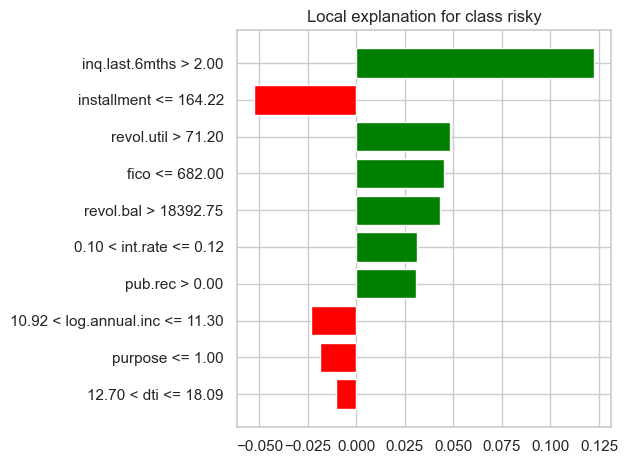

In [18]:
# LIME local explanation for one selected case
lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_t),
    feature_names=feature_names,
    class_names=['safe', 'risky'],
    mode='classification',
    random_state=RANDOM_SEED
)

case_for_lime = selected_cases[0] if selected_cases else X_val.index[0]
case_pos = X_val.index.get_loc(case_for_lime)
exp = lime_explainer.explain_instance(
    data_row=np.asarray(X_val_t[case_pos]),
    predict_fn=model.predict_proba,
    num_features=10
)
print('LIME case:', case_for_lime)
_ = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

## M2 Reflection (Write Here)

For each of 3 cases, add:
- Why the model failed
- Which features drove the decision
- Whether the explanation seems plausible to domain stakeholders

## Answers:
### Case 7992 - False Positive (predicted risky, actually safe)

Why the model failed: The model mistook short-term financial stress signals for default risk. The borrower had multiple recent credit inquiries, high revolving utilization, and a public record, a pattern the model associates with default, eventhough the borrower ultimately repaid.

Features that drove the decision: inq.last.6mths was the dominant driver (SHAP +1.33, LIME confirms largest green bar), followed by revol.util and fico <= 682. Interest rate and revolving balance were secondary contributors.

Domain plausibility: Partially plausible — credit inquiries and utilization are legitimate risk signals. However flagging a borrower purely on behavioral stress indicators without accounting for repayment capacity is an over-aggressive risk posture that could unfairly deny credit to borrowers experiencing temporary financial pressure.

## M3: Global Audit

Deliverable requirements:
1. Global feature ranking.
2. PDP for top numeric drivers.
3. One interaction finding with evidence.

In [ ]:
perm = permutation_importance(
    estimator=model,
    X=X_val_t,
    y=y_val,
    n_repeats=8,
    random_state=RANDOM_SEED,
    scoring='roc_auc'
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)
display(importance_df.head(15))

plt.figure(figsize=(8, 5))
top = importance_df.head(12).iloc[::-1]
plt.barh(top['feature'], top['importance_mean'])
plt.title('Permutation Importance (Validation)')
plt.xlabel('Mean ROC-AUC Drop')
plt.tight_layout()
plt.show()

In [ ]:
top_numeric = [f for f in importance_df['feature'].tolist() if f in numeric_cols][:2]
if not top_numeric:
    print('No numeric features found for PDP.')
else:
    idxs = [feature_names.index(f) for f in top_numeric]
    fig, ax = plt.subplots(1, len(idxs), figsize=(6 * len(idxs), 4))
    if len(idxs) == 1:
        ax = [ax]
    PartialDependenceDisplay.from_estimator(model, X_val_t, idxs, feature_names=feature_names, ax=ax)
    plt.suptitle('PDP: Top Numeric Features', y=1.03)
    plt.tight_layout()
    plt.show()

In [ ]:
# TODO: Choose two features for interaction analysis and justify your choice in markdown.
candidate_features = importance_df['feature'].head(10).tolist()
print('Top candidates:', candidate_features)

feature_a = None  # TODO set, e.g., 'dti'
feature_b = None  # TODO set, e.g., 'annual_inc'

if feature_a is None or feature_b is None:
    raise ValueError('Set feature_a and feature_b before running interaction analysis.')

if feature_a not in feature_names or feature_b not in feature_names:
    raise ValueError('Chosen features must be present in feature_names.')

i1, i2 = feature_names.index(feature_a), feature_names.index(feature_b)
X_inter = X_val_t[np.random.default_rng(RANDOM_SEED).choice(np.arange(X_val_t.shape[0]), size=min(800, X_val_t.shape[0]), replace=False)]

inter_explainer = shap.TreeExplainer(model)
inter_vals = inter_explainer.shap_interaction_values(X_inter)
if isinstance(inter_vals, list):
    inter_vals = inter_vals[1] if len(inter_vals) > 1 else inter_vals[0]

strength = np.abs(inter_vals[:, i1, i2]).mean()
print(f'SHAP mean |interaction| between {feature_a} and {feature_b}: {strength:.5f}')
shap.dependence_plot(i1, inter_explainer.shap_values(X_inter), X_inter, feature_names=feature_names, interaction_index=i2, show=False)
plt.title(f'SHAP Dependence: {feature_a} colored by {feature_b}')
plt.tight_layout()
plt.show()

## M3 Reflection (Write Here)

- What are the top 3 globally important features?
- Which PDP patterns look non-linear?
- What hidden interaction rule did you find?

## M4: Slicing Analysis and Audit Report

Deliverable requirements:
1. Choose subgroup column(s) and report per-group metrics.
2. Identify one group with significant performance weakness.
3. Propose a practical fix (data vs features vs both).

In [ ]:
slice_candidates = ['home_ownership', 'purpose', 'grade', 'sub_grade', 'emp_length', 'addr_state', 'verification_status']
available = [c for c in slice_candidates if c in X_val.columns]
print('Available slice columns:', available)

# TODO: Manually choose one available slice column and justify choice in markdown.
slice_col = None

if slice_col is None:
    raise ValueError('Set slice_col to one of the available slice columns.')
print('Chosen slice column:', slice_col)

In [ ]:
tmp = pd.DataFrame({
    'group': X_val[slice_col].astype(str).fillna('missing'),
    'y_true': y_val.values,
    'y_prob': val_proba
})
tmp['y_pred'] = (tmp['y_prob'] >= threshold).astype(int)

rows = []
for g, part in tmp.groupby('group'):
    if len(part) < 50:
        continue
    # TODO: compute at least AUC and F1 for each slice; add one extra metric of your choice.
    auc = roc_auc_score(part['y_true'], part['y_prob']) if part['y_true'].nunique() > 1 else np.nan
    f1 = f1_score(part['y_true'], part['y_pred']) if part['y_true'].nunique() > 1 else np.nan
    metric_extra = np.nan  # TODO replace with your chosen metric
    rows.append({
        'group': g,
        'n': len(part),
        'positive_rate': part['y_true'].mean(),
        'auc': auc,
        'f1': f1,
        'metric_extra': metric_extra
    })

slice_report = pd.DataFrame(rows).sort_values(['f1', 'auc'], na_position='last')
display(slice_report.head(20))

## Final Audit Report (Write Here)

Use this exact structure:
1. Executive Summary (5-8 lines)
2. M1 Findings: model quality and threshold rationale
3. M2 Findings: 3 local failure case explanations
4. M3 Findings: global importance, PDP, interaction rule
5. M4 Findings: subgroup failure and risk concentration
6. Recommended Fix: data vs feature vs combined
7. Limitations and Monitoring Plan

## Submission Checklist

- [ ] Workbook completed with all milestone reflections
- [ ] Model artifact saved in artifacts/
- [ ] At least 3 local error explanations included
- [ ] At least 1 interaction effect documented
- [ ] Slicing analysis table included
- [ ] Final audit report completed